In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from PIL import Image
# model Support Vector Machine
from sklearn.svm import SVC, LinearSVC
# funkcje do generowania przykładowych zbiorów danych
from sklearn.datasets import make_blobs, make_moons, make_circles
# algorytm PCA (do redukcji wymiarów danych)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# pozwala łączyć kilka kroków przetwarzania danych w jeden pipelin
from sklearn.pipeline import make_pipeline
# funkcja do mierzenia dokładności modelu
from sklearn.metrics import accuracy_score

In [29]:
def load_images(folder, size=(96, 96)):
    X = []
    y = []
    
    #tworzymy liste klas
    class_names = sorted(os.listdir(folder))

    #kazdemu gatunkowi przypisujemy numer
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            
            #obrazy na czarno-biale i skalowanie
            img = cv2.imread(file_path)
            if img is None:
                continue
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, size)

            #obraz->macierz->wektor
            X.append(np.array(img).flatten())
            y.append(label)
            
            rotated = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
            X.append(rotated.flatten())
            y.append(label)
            
            rotated = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
            X.append(rotated.flatten())
            y.append(label)
            
    return np.array(X), np.array(y), class_names

In [30]:
X_train, y_train, class_names = load_images("data/Train_Test_Valid/Train")
X_test, y_test, class_names = load_images("data/Train_Test_Valid/test")
print(X_train.shape)
print(y_train.shape)

(2700, 27648)
(2700,)


Klasy: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
X_train shape: (2700, 27648)
y_train shape: (2700,)


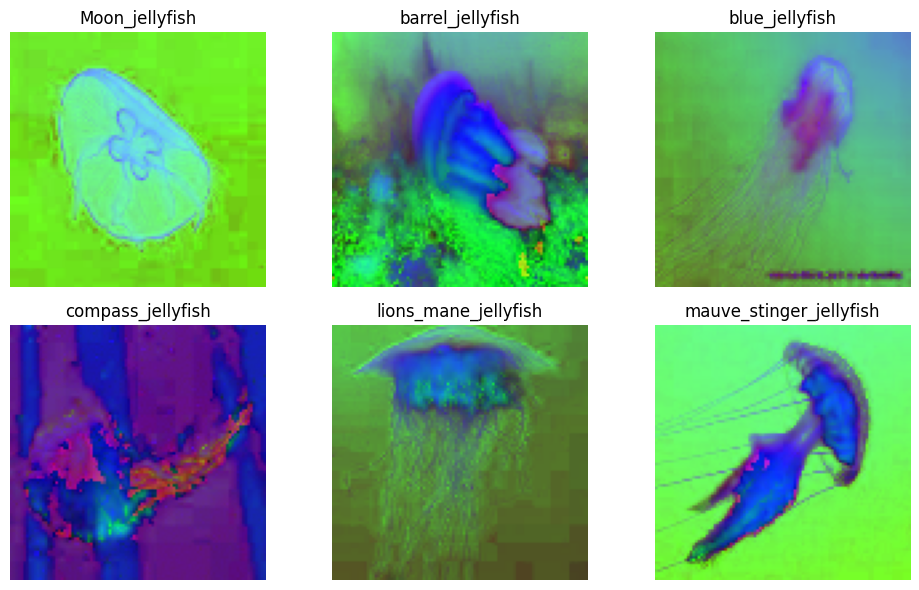

In [31]:
print("Klasy:", class_names)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
#900 obrazow, 9216cech

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
for label, axi in enumerate(ax.flat):
    idx = np.where(y_train == label)[0][0]   # pierwszy obraz z danej klasy
    axi.imshow(X_train[idx].reshape(96, 96, 3))
    axi.set_title(class_names[label])
    axi.axis("off")

plt.tight_layout()
plt.show()

In [32]:
#spr

from collections import Counter

counts = Counter(y_train)

for label, count in counts.items():
    print(label, ":", count)

0 : 450
1 : 450
2 : 450
3 : 450
4 : 450
5 : 450


In [33]:
model = make_pipeline(
    StandardScaler(),
    PCA(n_components=100, whiten=True, svd_solver='randomized', random_state=42),
    SVC(kernel='rbf', class_weight='balanced')
)

In [ ]:
from sklearn.model_selection import GridSearchCV

#szukamy najlepszych parametrów do modelu
param_grid = {
    'svc__C': [1, 2, 4],
    'svc__gamma': ['scale', 0.0005, 0.005]
}

grid = GridSearchCV(model, param_grid)

grid.fit(X_train, y_train)

print(grid.best_params_)

In [24]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy [%]:", acc * 100)

Accuracy [%]: 57.49999999999999


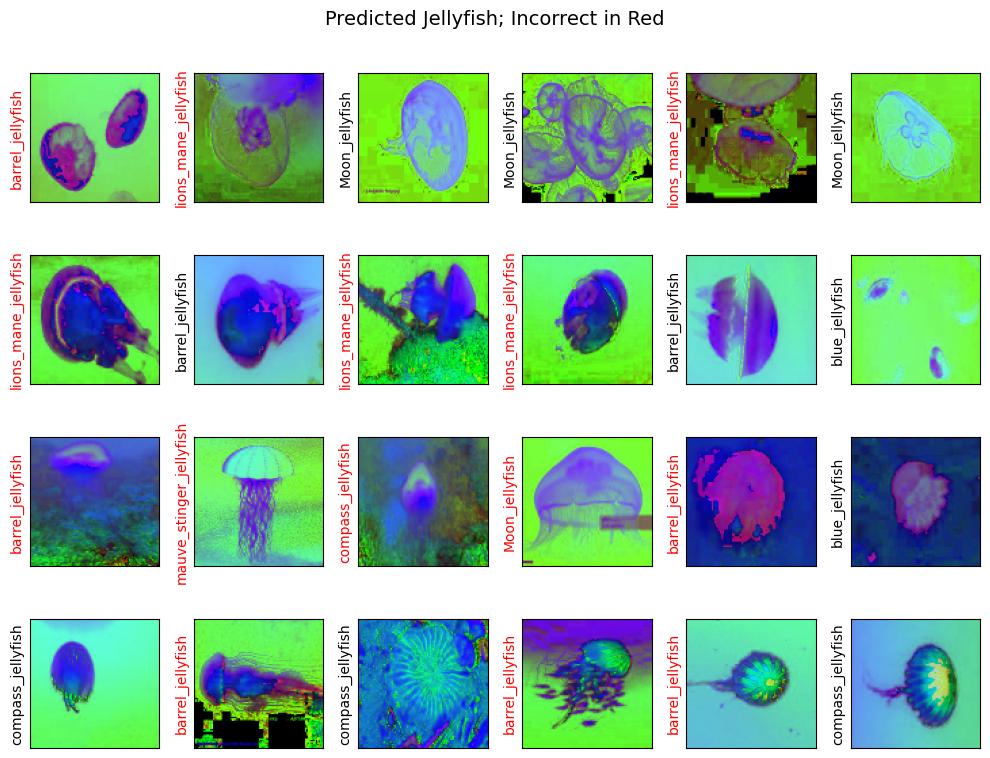

In [9]:
fig, ax = plt.subplots(4, 6, figsize=(10, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i].reshape(96, 96, 3), cmap='gray')
    axi.set(xticks=[], yticks=[])

    axi.set_ylabel(
        class_names[y_pred[i]],
        color='black' if y_pred[i] == y_test[i] else 'red'
    )

fig.suptitle('Predicted Jellyfish; Incorrect in Red', size=14)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
                            target_names=class_names))

                         precision    recall  f1-score   support

         Moon_jellyfish       0.50      0.50      0.50         6
       barrel_jellyfish       0.25      0.40      0.31         5
         blue_jellyfish       1.00      0.29      0.44         7
      compass_jellyfish       0.40      0.57      0.47         7
   lions_mane_jellyfish       0.40      0.50      0.44         8
mauve_stinger_jellyfish       0.75      0.43      0.55         7

               accuracy                           0.45        40
              macro avg       0.55      0.45      0.45        40
           weighted avg       0.56      0.45      0.46        40

